# Linear Regression

## Import Libraries

In [1]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported! ✅")

Libraries imported! ✅


## Loading the House Dataset

In [2]:
# Load the dataset - using sep='\s+' because values are separated by spaces
df = pd.read_csv(r"C:\Users\MINHAJ\Downloads\Data Set For Task-20260408T161732Z-3-001\Data Set For Task\4) house Prediction Data Set.csv", 
                 header=None, 
                 sep=r'\s+')   # \s+ means "one or more spaces"

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (506, 14)

First 5 rows:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [3]:
df.columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 
              'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 
              'LSTAT', 'PRICE']

print("Columns added! ✅")
print("\nColumn names:", list(df.columns))
print("\nFirst 5 rows:")
df.head()

Columns added! ✅

Column names: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'PRICE']

First 5 rows:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## Check Missing Values

In [4]:
print("=== Dataset Info ===")
df.info()

print("\n=== Basic Statistics ===")
print(df.describe())

print("\n=== Missing Values ===")
print(df.isnull().sum())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  PRICE    506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB

=== Basic Statistics ===
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363

In [5]:
# X = all columns EXCEPT price (these are our inputs)
# y = PRICE column (this is what we want to predict)

X = df.drop('PRICE', axis=1)
y = df['PRICE']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nSample target values (house prices):", y.head().values)

Features shape: (506, 13)
Target shape: (506,)

Sample target values (house prices): [24.  21.6 34.7 33.4 36.2]


In [6]:
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Scaling and splitting done! ✅")

Training samples: 404
Testing samples: 102
Scaling and splitting done! ✅


In [7]:
# Create the model
model = LinearRegression()

# Train it — this is where the magic happens!
model.fit(X_train, y_train)

print("Model trained! ✅")
print("\nModel Coefficients (one per feature):")
for feature, coef in zip(df.columns[:-1], model.coef_):
    print(f"  {feature}: {coef:.4f}")

print(f"\nIntercept: {model.intercept_:.4f}")

Model trained! ✅

Model Coefficients (one per feature):
  CRIM: -0.9715
  ZN: 0.7016
  INDUS: 0.2768
  CHAS: 0.7065
  NOX: -1.9914
  RM: 3.1157
  AGE: -0.1771
  DIS: -3.0458
  RAD: 2.2828
  TAX: -1.7926
  PTRATIO: -1.9800
  B: 1.1265
  LSTAT: -3.6281

Intercept: 22.4853


In [8]:
# Make predictions on test data
y_pred = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=" * 40)
print("      MODEL EVALUATION RESULTS")
print("=" * 40)
print(f"Mean Squared Error (MSE):  {mse:.2f}")
print(f"Root MSE (RMSE):           {rmse:.2f}")
print(f"R-squared (R²):            {r2:.4f}")
print("=" * 40)
print(f"\nInterpretation:")
print(f"  R² = {r2:.2%} of price variation explained by model")

      MODEL EVALUATION RESULTS
Mean Squared Error (MSE):  24.29
Root MSE (RMSE):           4.93
R-squared (R²):            0.6688

Interpretation:
  R² = 66.88% of price variation explained by model


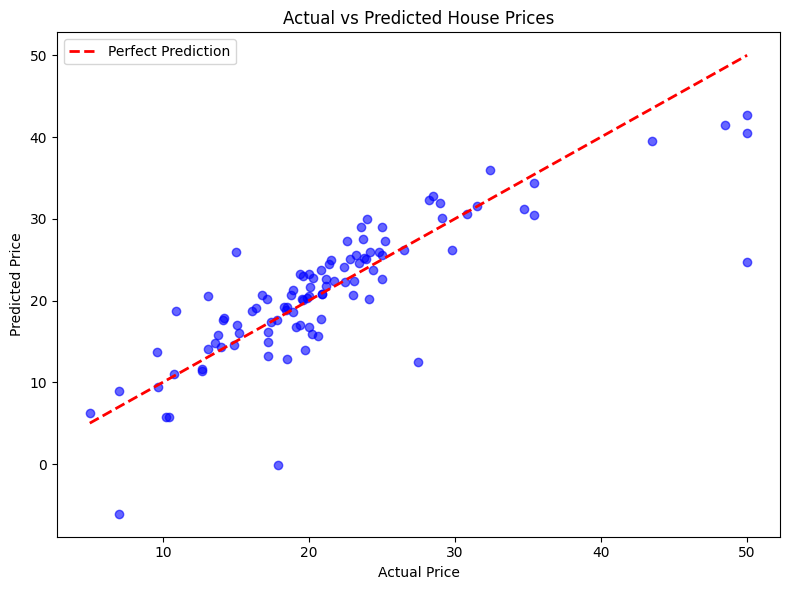

Plot saved! ✅


In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.tight_layout()
plt.savefig("actual_vs_predicted.png")
plt.show()
print("Plot saved! ✅")